In [1]:





import geopandas as gd


In [2]:
import pandas as pd


In [8]:
geo_municipios = gd.read_file("../data/raw/MGMPIGRAFICO/MGN_ADM_MPIO_GRAFICO.shp")

In [4]:
!pwd

/mnt/c/Users/TUPTC/bigdata/big-data-postgraduate/kit/Notebooks


In [9]:
import matplotlib as mp

<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

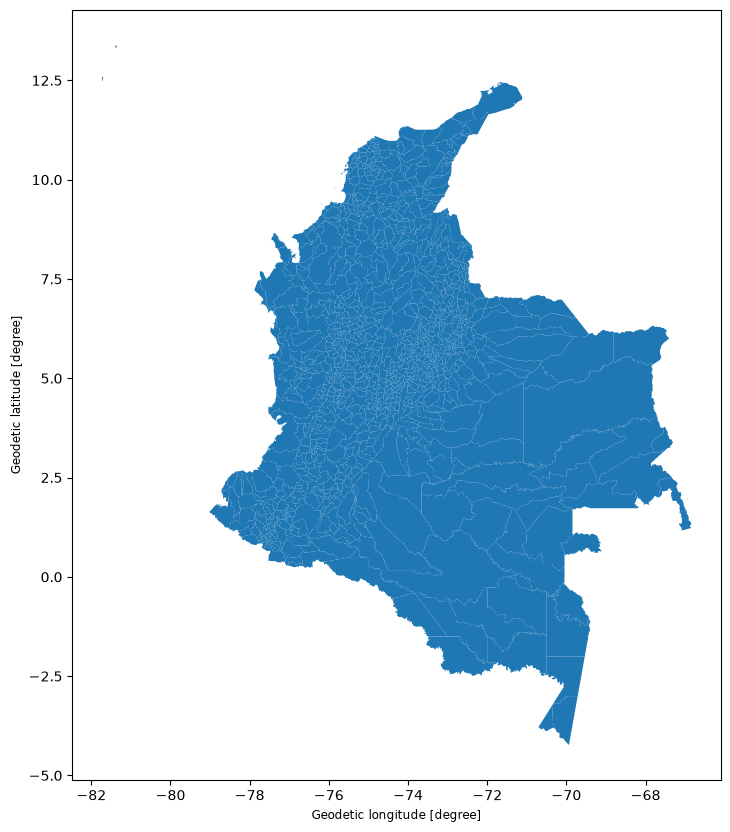

In [14]:
geo_municipios.plot(figsize = (10,10) )

In [15]:
geo_municipios.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   dpto_ccdgo  1122 non-null   object  
 1   mpio_ccdgo  1122 non-null   object  
 2   mpio_cdpmp  1122 non-null   object  
 3   dpto_cnmbr  1122 non-null   object  
 4   mpio_cnmbr  1122 non-null   object  
 5   mpio_crslc  1122 non-null   object  
 6   mpio_tipo   1122 non-null   object  
 7   mpio_narea  1122 non-null   float64 
 8   mpio_nano   1122 non-null   int32   
 9   shape_Leng  1122 non-null   float64 
 10  shape_Area  1122 non-null   float64 
 11  geometry    1122 non-null   geometry
dtypes: float64(3), geometry(1), int32(1), object(7)
memory usage: 100.9+ KB


In [17]:
geo_municipios.head(5)

,dpto_ccdgo,mpio_ccdgo,mpio_cdpmp,dpto_cnmbr,mpio_cnmbr,mpio_crslc,mpio_tipo,mpio_narea,mpio_nano,shape_Leng,shape_Area,geometry
0,05,001,05001,ANTIOQUIA,MEDELLÍN,1965,MUNICIPIO,374.741484,2025,1.035380,0.030608,"POLYGON ((-75.4857 6.20163, -75.48567 6.20148,..."
1,05,002,05002,ANTIOQUIA,ABEJORRAL,1814,MUNICIPIO,506.959782,2024,1.158504,0.041384,"POLYGON ((-75.46938 5.94575, -75.46897 5.94571..."
2,05,004,05004,ANTIOQUIA,ABRIAQUÍ,1912,MUNICIPIO,296.974188,2025,0.810667,0.024253,"POLYGON ((-76.09047 6.74542, -76.09066 6.74548..."
3,05,021,05021,ANTIOQUIA,ALEJANDRÍA,Decreto departamental 304 de 1907,MUNICIPIO,128.856431,2024,0.705200,0.010535,"POLYGON ((-75.0332 6.41586, -75.03313 6.41585,..."
4,05,030,05030,ANTIOQUIA,AMAGÁ,1912,MUNICIPIO,84.117145,2024,0.445533,0.006867,"POLYGON ((-75.67587 6.08561, -75.6754 6.08491,..."


In [20]:
print(geo_municipios.columns)

Index(['dpto_ccdgo', 'mpio_ccdgo', 'mpio_cdpmp', 'dpto_cnmbr', 'mpio_cnmbr',
       'mpio_crslc', 'mpio_tipo', 'mpio_narea', 'mpio_nano', 'shape_Leng',
       'shape_Area', 'geometry'],
      dtype='object')


<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

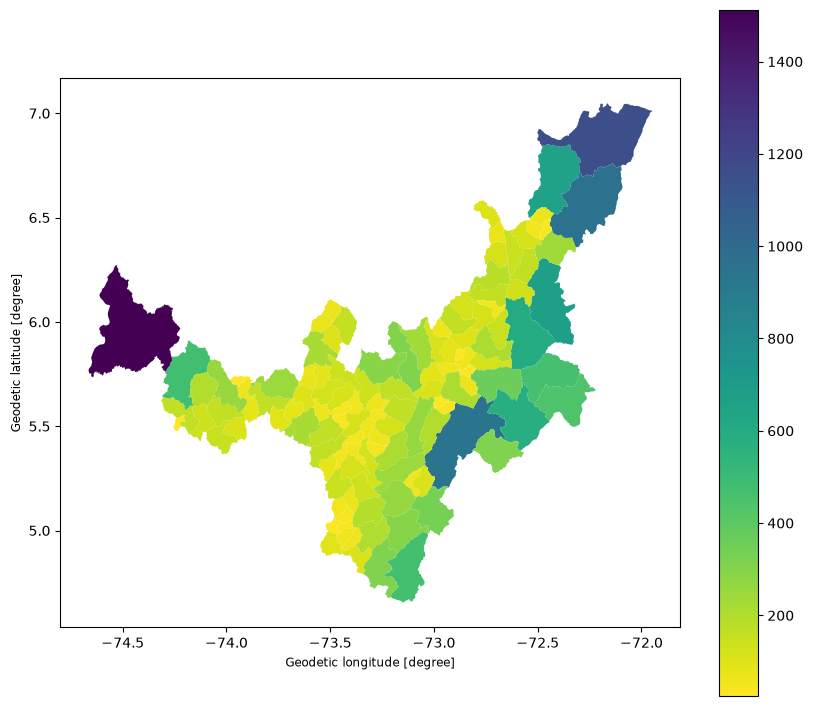

In [28]:
boyaca_municipios = geo_municipios[geo_municipios['dpto_cnmbr'] == 'BOYACÁ']
boyaca_municipios.plot(figsize=(10, 10), cmap="viridis_r", column="mpio_narea", legend=True)

In [30]:
boyaca_municipios = geo_municipios[geo_municipios['dpto_cnmbr'] == 'BOYACÀ']

# Verificar cuántos municipios encontró
print(f"Municipios de Boyacá encontrados: {len(boyaca_municipios)}")

Municipios de Boyacá encontrados: 0


In [36]:
df_divipola = pd.read_csv("../data/raw/divipola.csv")
df_eva = pd.read_csv("../data/raw/eva.csv")

In [45]:
departamentos = df_divipola.sort_values(by=["Código Departamento"], ascending=True)["Código Departamento"]
departamentos.unique()


array([ 5,  8, 11, 13, 15, 17, 18, 19, 20, 23, 25, 27, 41, 44, 47, 50, 52,
       54, 63, 66, 68, 70, 73, 76, 81, 85, 86, 88, 91, 94, 95, 97, 99])

In [46]:
departamentos_dane = geo_municipios.sort_values(by=["dpto_ccdgo"], ascending=True)["dpto_ccdgo"]
departamentos_dane.unique()

array(['05', '08', '11', '13', '15', '17', '18', '19', '20', '23', '25',
       '27', '41', '44', '47', '50', '52', '54', '63', '66', '68', '70',
       '73', '76', '81', '85', '86', '88', '91', '94', '95', '97', '99'],
      dtype=object)

In [50]:
Dep_dane_num = departamentos_dane.astype ("int64")

In [52]:
departamentos_dane.info()

<class 'pandas.core.series.Series'>
Index: 1122 entries, 0 to 1121
Series name: dpto_ccdgo
Non-Null Count  Dtype 
--------------  ----- 
1122 non-null   object
dtypes: object(1)
memory usage: 17.5+ KB


In [55]:
departamentos_dane.notnull().sum()

np.int64(1122)

In [56]:
departamentos.notnull().sum()

np.int64(1122)

In [57]:
len(departamentos_dane.unique())

33

In [58]:
len(departamentos_dane.unique())

33

In [59]:
df_eva.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166732 entries, 0 to 166731
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Código Dane departamento       166732 non-null  int64  
 1   Departamento                   166732 non-null  object 
 2   Código Dane municipio          166732 non-null  int64  
 3   Municipio                      166732 non-null  object 
 4   Grupo cultivo                  166732 non-null  object 
 5   Subgrupo                       166732 non-null  object 
 6   Cultivo                        166732 non-null  object 
 7   Desagregación cultivo          166732 non-null  object 
 8   Año                            166732 non-null  int64  
 9   Periodo                        166732 non-null  object 
 10  Área sembrada                  166732 non-null  float64
 11  Área cosechada                 166732 non-null  float64
 12  Producción                    

In [61]:
departamentos_eva = df_eva.sort_values(by=["Código Dane departamento"], ascending=True)["Código Dane departamento"]

In [62]:
departamentos_eva.unique()

array([ 5,  8, 13, 15, 17, 18, 19, 20, 23, 25, 27, 41, 44, 47, 50, 52, 54,
       63, 66, 68, 70, 73, 76, 81, 85, 86, 88, 91, 94, 95, 97, 99])

In [63]:
len(departamentos_eva.unique())

32

In [64]:
import numpy as np

In [67]:
res = np.nonzero(np.isin(departamentos_eva.unique(),departamentos))[0]
display(res)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [ ]:
display(departamentos_eva.unique()[~departamentos_eva.unique().isin(departamentos.unique()])

In [68]:
a=pd.Series(departamentos_eva.unique())

In [69]:
b=pd.Series(departamentos.unique())

In [77]:
df_divipola[~df_divipola['Código Departamento'].isin(df_eva['Código Dane departamento'])]

,Código Departamento,Nombre Departamento,Código Municipio,Nombre Municipio,Tipo: Municipio / Isla / Área no municipalizada,longitud,Latitud
148,11,"BOGOTÁ, D.C.",11001,"BOGOTÁ, D.C.",Municipio,"-74,106992","4,649251"
